# Total Bars

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--update-ratio', '0.005', '--probe-ratio', '0.005', '--txn-count', '40', '--scan-count', '6', '--warehouse-count', '5', '--scan-reuse-ratio', '0.8', '--analytical-ratio', '0.6', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
probe ratio: 0.005
Analytical ratio: Some(0.6)
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.4)
Transactions Probe ratio: Some(0.24)
Transactions Scan ratio: Some(0.24)
Transactions Delta Scan ratio: Some(0.12)
-------------------------------------------------

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,naive,90.406183,150000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,naive,89.368083,150000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,naive,89.676934,150000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,naive,117.079109,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,naive,117.109337,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,naive,116.300394,NaN,1.0,NaN,NaN
6,2,2,Scan,No Repair,naive,72.717879,NaN,1.0,NaN,NaN
7,2,2,Scan,Read Repair,naive,83.840547,NaN,1.0,NaN,NaN
8,2,2,Scan,Write Repair,naive,85.439411,NaN,1.0,NaN,NaN
9,3,3,Probe,No Repair,naive,127.520947,750.0,1.0,NaN,NaN


duration_max: 320.594528


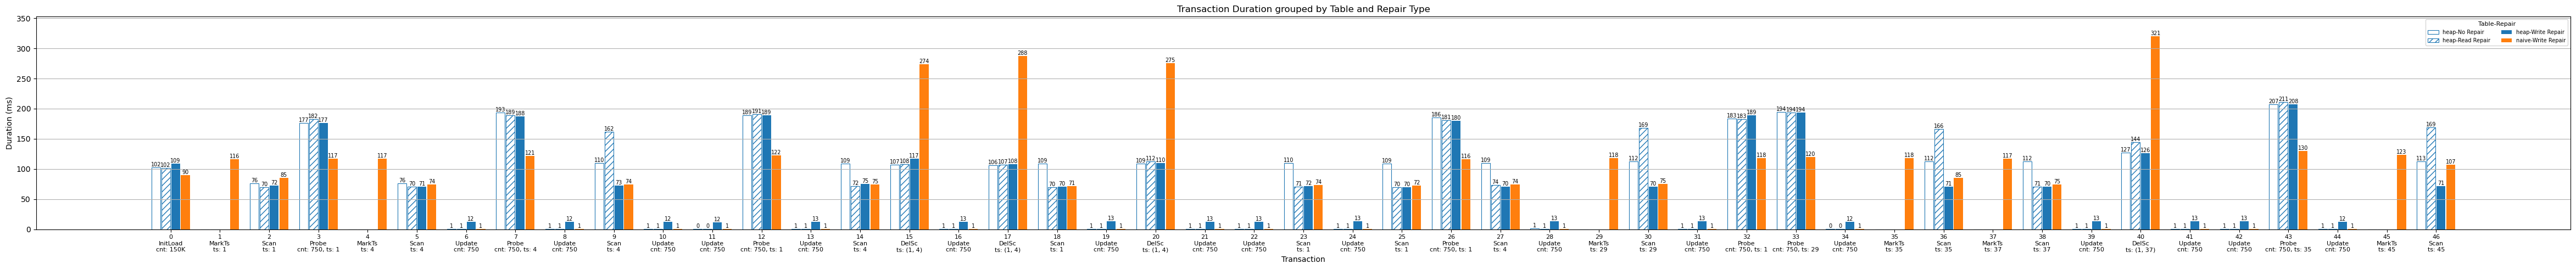

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.005",  # update ratio, % of base table
    "--probe-ratio", "0.0005",
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "5", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-ratio", "0.6"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap"] # , "par", "chain"

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
from bench_script_functions import run_and_collect
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# Space Statistics

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.01', '--txn-count', '25', '--scan-count', '6', '--warehouse-count', '40', '--space-stat', 'on', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.01
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 25
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1200000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 12000
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 

,table_type,repair_type,total_space,all_versions_space,valid_space
0,naive,No Repair,3705667584,3436800000,859200000
1,heap,No Repair,1093402624,996672000,859200000
2,par,No Repair,1176764416,996672000,859200000
3,chain,No Repair,1109917696,996672000,859200000


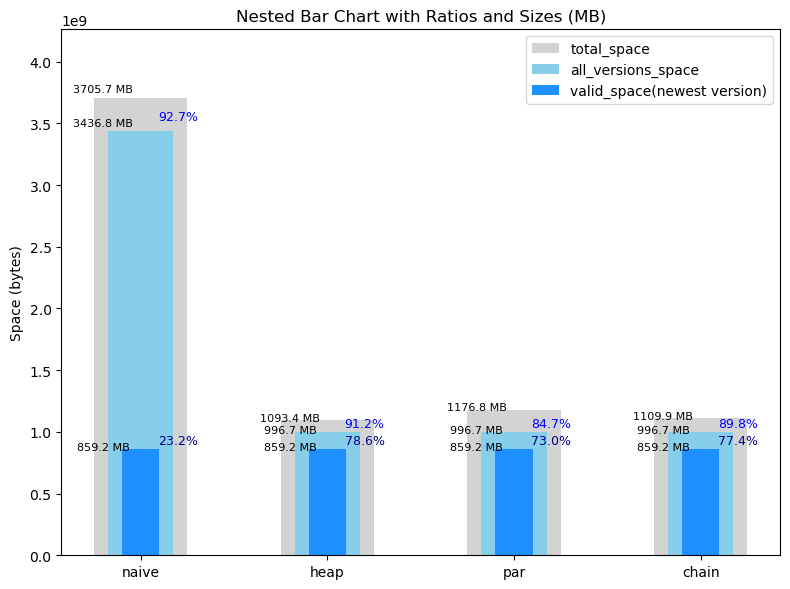

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--update-ratio", "0.01",  # update ratio, % of base table
    "--probe-ratio", "0.0005",
    "--txn-count", "25",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "40" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect_space
new_args = BASE_ARGS + ["--space-stat", "on"]

df = run_and_collect_space(BIN, TABLE_TYPES, new_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)

def plot_nested_space(df):
    for col in ["total_space", "all_versions_space", "valid_space"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
    df["valid_ratio"] = df["valid_space"] / df["total_space"]

    fig, ax = plt.subplots(figsize=(8,6))
    bar_width = 0.5

    ax.bar(df["table_type"], df["total_space"], 
           color="lightgray", width=bar_width, label="total_space")
    ax.bar(df["table_type"], df["all_versions_space"], 
           color="skyblue", width=bar_width*0.7, label="all_versions_space")
    ax.bar(df["table_type"], df["valid_space"], 
           color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

    for i, row in df.iterrows():
        total_mb = row["total_space"] / 1e6
        all_versions_mb = row["all_versions_space"] / 1e6
        valid_mb = row["valid_space"] / 1e6

        ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")

        ax.text(i + 0.2, row["all_versions_space"] * 1.02,
                f"{row['all_versions_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="blue")
        ax.text(i + 0.2, row["valid_space"] * 1.02,
                f"{row['valid_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="darkblue")

    ax.set_ylabel("Space (bytes)")
    max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
    ax.set_ylim(0, max_value * 1.15)
    ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_nested_space(df)



# Stacked Bar Chart -- Extremely Analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--scan-reuse-ratio', '0.8', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.93', '--txn-gc-ratio', '0.03', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.93)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.03999999999999995)
Transactions Probe ratio: Some(0.3069)
Transactions Scan ratio: Some(0.3069)
Transactions Delta Scan ratio: 

,tx_type,count
0,DelSc,19
1,GbgCollect,2
2,InitLoad,1
3,MarkTs,4
4,Probe,18
5,Scan,19
6,Update,4


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,21369.038221
1,chain,Write Repair,GbgCollect,0.341292
2,chain,Write Repair,InitLoad,748.801809
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,2748.260075
5,chain,Write Repair,Scan,12184.304169
6,chain,Write Repair,Update,360.402619
7,heap,No Repair,DelSc,22773.930209
8,heap,No Repair,GbgCollect,603.988954
9,heap,No Repair,InitLoad,751.133831


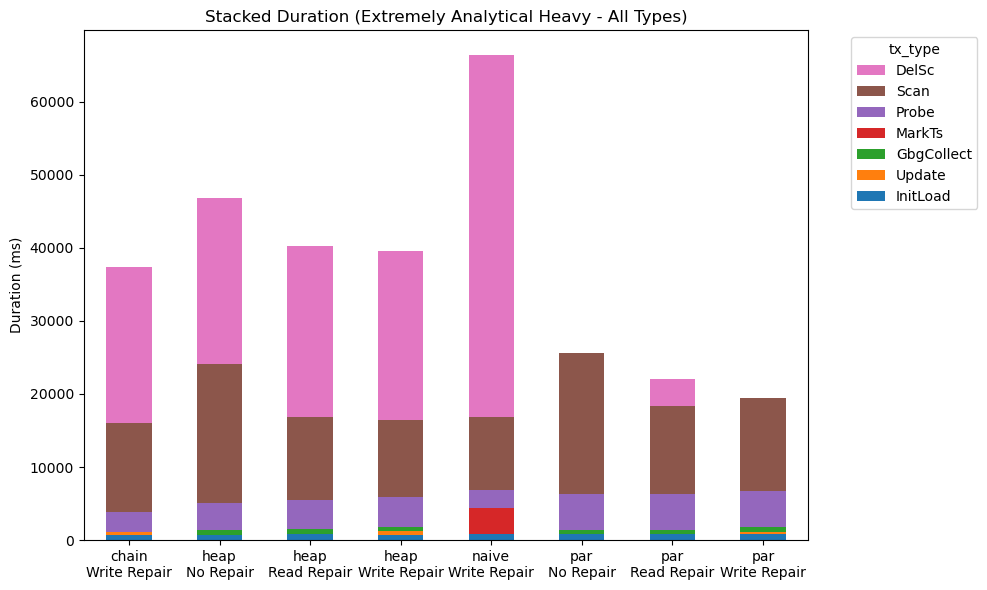

In [1]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Extremely Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",
    "--warehouse-count", "35", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] # , "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)
    filtered = df[(df["table_type"] == "heap") & (df["repair_type"] == "No Repair")]

    # Group by tx_type and sum duration_ms
    agg = filtered.groupby("tx_type").size().reset_index(name="count")
    display(agg)
    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.93",
    "--txn-gc-ratio", "0.03"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--scan-reuse-ratio', '0.8', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.80', '--txn-gc-ratio', '0.03', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.8)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.16999999999999996)
Transactions Probe ratio: Some(0.264)
Transactions Scan ratio: Some(0.264)
Transactions Delta Scan ratio: Some(0.27199999999999996)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_ty

,tx_type,count
0,DelSc,16
1,GbgCollect,1
2,InitLoad,1
3,MarkTs,4
4,Probe,16
5,Scan,16
6,Update,12


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,18211.415799
1,chain,Write Repair,GbgCollect,0.211067
2,chain,Write Repair,InitLoad,762.629280
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,2404.085710
5,chain,Write Repair,Scan,10363.661525
6,chain,Write Repair,Update,1097.051411
7,heap,No Repair,DelSc,19443.319075
8,heap,No Repair,GbgCollect,290.611429
9,heap,No Repair,InitLoad,750.168392


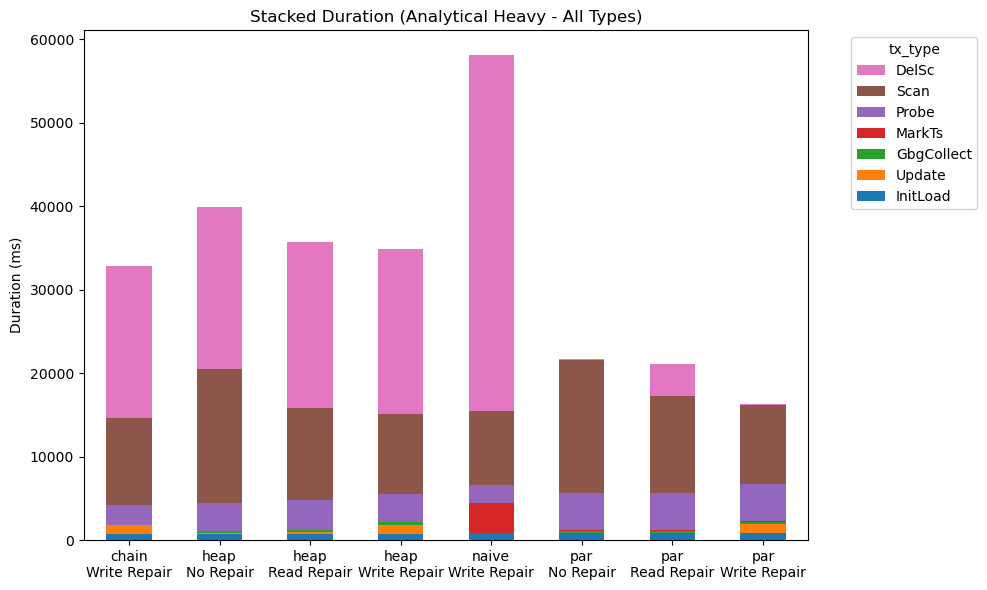

In [2]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)
    filtered = df[(df["table_type"] == "heap") & (df["repair_type"] == "No Repair")]

    # Group by tx_type and sum duration_ms
    agg = filtered.groupby("tx_type").size().reset_index(name="count")
    display(agg)
    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.80",
    "--txn-gc-ratio", "0.03"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- Hybrid

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--scan-reuse-ratio', '0.8', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.50', '--txn-gc-ratio', '0.03', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.5)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.47)
Transactions Probe ratio: Some(0.165)
Transactions Scan ratio: Some(0.165)
Transactions Delta Scan ratio: Some(0.16999999999999998)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update,

,tx_type,count
0,DelSc,10
1,GbgCollect,2
2,InitLoad,1
3,MarkTs,4
4,Probe,10
5,Scan,10
6,Update,30


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,11806.511745
1,chain,Write Repair,GbgCollect,1.258793
2,chain,Write Repair,InitLoad,736.728892
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,1537.448440
5,chain,Write Repair,Scan,6648.305230
6,chain,Write Repair,Update,2745.395983
7,heap,No Repair,DelSc,12670.982908
8,heap,No Repair,GbgCollect,597.301055
9,heap,No Repair,InitLoad,748.787733


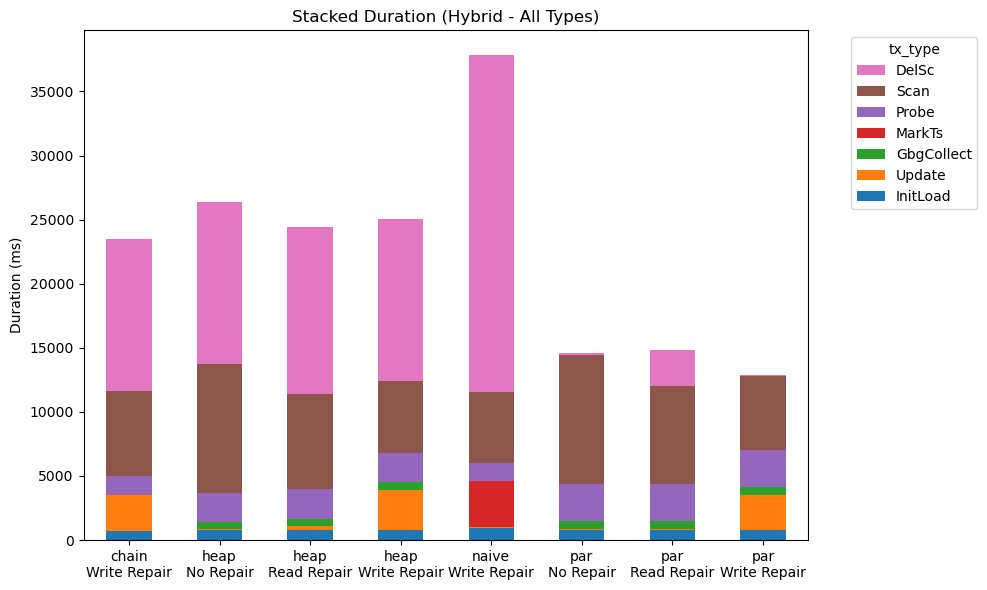

In [3]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Hybrid"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)
    filtered = df[(df["table_type"] == "heap") & (df["repair_type"] == "No Repair")]

    # Group by tx_type and sum duration_ms
    agg = filtered.groupby("tx_type").size().reset_index(name="count")

    display(agg)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.50",
    "--txn-gc-ratio", "0.03"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- Transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--scan-reuse-ratio', '0.8', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.20', '--txn-gc-ratio', '0.03', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.2)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.77)
Transactions Probe ratio: Some(0.066)
Transactions Scan ratio: Some(0.066)
Transactions Delta Scan ratio: Some(0.06799999999999999)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update,

,tx_type,count
0,DelSc,4
1,GbgCollect,1
2,InitLoad,1
3,MarkTs,3
4,Probe,4
5,Scan,4
6,Update,48


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,4641.959879
1,chain,Write Repair,GbgCollect,0.749842
2,chain,Write Repair,InitLoad,742.819286
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,631.736329
5,chain,Write Repair,Scan,2609.904995
6,chain,Write Repair,Update,4321.604430
7,heap,No Repair,DelSc,4812.360509
8,heap,No Repair,GbgCollect,292.887603
9,heap,No Repair,InitLoad,747.765616


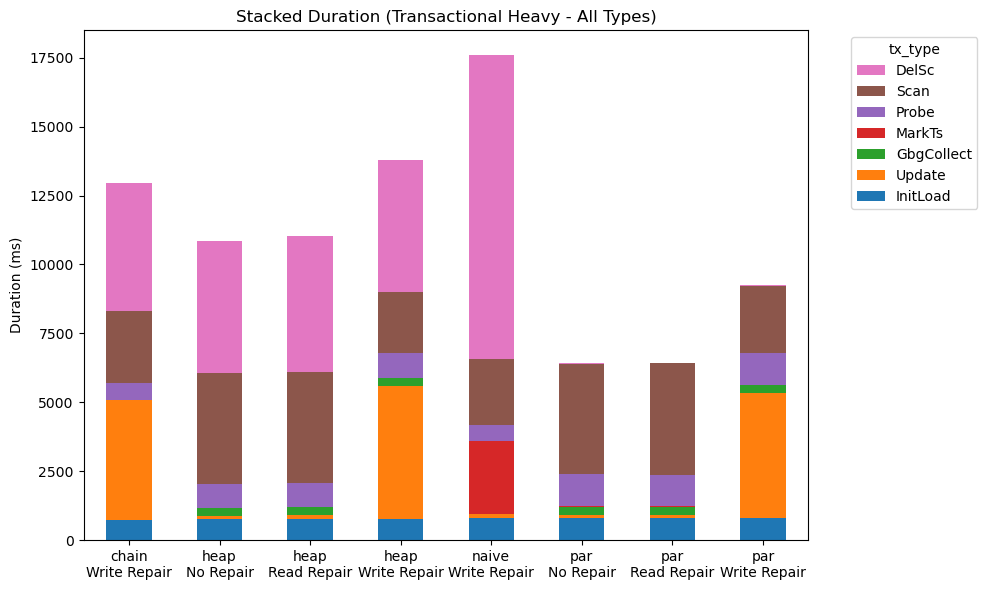

In [4]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)
    filtered = df[(df["table_type"] == "heap") & (df["repair_type"] == "No Repair")]

    # Group by tx_type and sum duration_ms
    agg = filtered.groupby("tx_type").size().reset_index(name="count")

    display(agg)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.20",
    "--txn-gc-ratio", "0.03"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart -- Extremely Transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--scan-reuse-ratio', '0.8', '--analytical-uniform', 'on', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--analytical-ratio', '0.05', '--txn-gc-ratio', '0.03', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.05)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.9199999999999999)
Transactions Probe ratio: Some(0.0165)
Transactions Scan ratio: Some(0.0165)
Transactions Delta Scan ratio: S

-----------------------------------------------------------------------
Hash table type: Heap
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: Some(0.05)
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.9199999999999999)
Transactions Probe ratio: Some(0.0165)
Transactions Scan ratio: Some(0.0165)
Transactions Delta Scan ratio: Some(0.016999999999999998)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_

,tx_type,count
0,DelSc,1
1,GbgCollect,1
2,InitLoad,1
3,MarkTs,3
4,Probe,1
5,Scan,1
6,Update,57


,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,1123.625082
1,chain,Write Repair,GbgCollect,0.907152
2,chain,Write Repair,InitLoad,739.473516
3,chain,Write Repair,MarkTs,0.000000
4,chain,Write Repair,Probe,159.588923
5,chain,Write Repair,Scan,692.800821
6,chain,Write Repair,Update,5059.729006
7,heap,No Repair,DelSc,1185.824972
8,heap,No Repair,GbgCollect,291.690645
9,heap,No Repair,InitLoad,765.319222


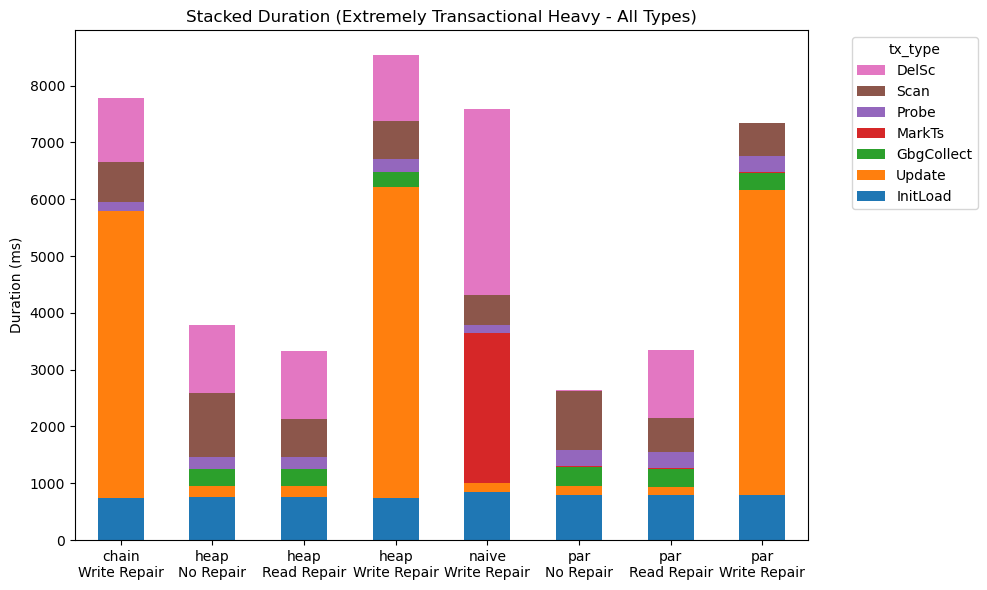

In [5]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Extremely Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--scan-reuse-ratio", "0.8",
    "--analytical-uniform", "on"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"

from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']

            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)
    filtered = df[(df["table_type"] == "heap") & (df["repair_type"] == "No Repair")]

    # Group by tx_type and sum duration_ms
    agg = filtered.groupby("tx_type").size().reset_index(name="count")

    display(agg)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum())) #  if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
    )
    display(result)

    draw_stack_bar(result, TITLE,  "All Types")

added_args = [
    "--update-ratio", "0.003",  # update ratio, 0.3% of base table
    "--probe-ratio", "0.0001",
    "--analytical-ratio", "0.05",
    "--txn-gc-ratio", "0.03"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Stacked Bar Chart  -- Extremely Reuse of Time

In [26]:
# import subprocess
# from pathlib import Path
# import pandas as pd
# import matplotlib.pyplot as plt
# import re

# TITLE = "Transactional Extremely Heavy"

# # ----------------------------------------
# # Build the Rust binary
# # ----------------------------------------
# print("=== Building Rust binary in release mode ===")
# build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
# result = subprocess.run(build_cmd, capture_output=True, text=True)
# if result.returncode != 0:
#     print("[ERROR] cargo build failed.\n", result.stderr)
#     raise SystemExit(1)
# print("Cargo build completed successfully.\n")


# BASE_ARGS = [
#     "--txn-count", "40",  
#     "--warehouse-count", "5" # linear to base table size
# ]
# REPEAT=1
# BIN = Path("../../../target/release/htap_wkld")
# TABLE_TYPES = [ "naive", "heap"]

# from bench_script_functions import run_and_collect, prepare_plot_data, draw_stack_bar

# def plot_all2(df):
#     color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

#     groups = []
#     for table_type in table_types:
#         if table_type in ["chain", "naive"]:
#             groups.append((table_type, "Write Repair"))
#         else:
#             for repair_type in repair_types:
#                 groups.append((table_type, repair_type))

#     print(groups)
#     type_and_durations = []
#     for i, (table_type, repair_type) in enumerate(groups):
#         if table_type in ["chain", "naive"] and repair_type != "Write Repair":
#             continue

#         df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

#         scan_count = 0

#         for idx in unique_idx:
#             df_row = df_group[df_group['idx'] == idx]
#             duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
#             label = dict_labels[idx]
#             cur_tx_type = label['tx_type']

#             # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
#             line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
#             type_and_durations.append(line)
#     # print(type_and_durations)
#     df = pd.DataFrame(type_and_durations)

#     result = (
#         df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
#         .agg(duration_ms=("duration_ms", lambda x: x.sum())) # if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()
#     )
#     display(result)

#     draw_stack_bar(result, TITLE, "All Types")

# added_args = [
#     "--analytical-ratio", "0.9",
#     "--scan-count", "10",
#     "--delta-count", "2",
#     "--update-ratio", "0.005",  # update ratio, % of base table
#     "--probe-ratio", "0.01"
# ]

# df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# # Display the resulting DataFrame
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# plot_all2(df)




# DELTA TRADEOFF -- delta scan

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.385', '--txn-delta-ratio', '0.0', '--txn-scan-ratio', '0.385', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.385)
Transactions Scan ratio: Some(0.385)
Transactions Delta Scan ratio: Some(0.0)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 3150
id

,tx_type,count,percentage
0,GbgCollect,2,3.1250
1,InitLoad,1,1.5625
2,MarkTs,11,17.1875
3,Probe,19,29.6875
4,Scan,19,29.6875
5,Update,12,18.7500


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.34500000000000003', '--txn-delta-ratio', '0.08', '--txn-scan-ratio', '0.34500000000000003', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.34500000000000003)
Transactions Scan ratio: Some(0.34500000000000003)
Transactions Delta Scan ratio: Some(0.08)
-----------

,tx_type,count,percentage
0,DeltaScan,4,6.451613
1,GbgCollect,2,3.225806
2,InitLoad,1,1.612903
3,MarkTs,9,14.516129
4,Probe,17,27.419355
5,Scan,17,27.419355
6,Update,12,19.354839


...

,tx_type,count,percentage
0,DeltaScan,7,11.475410
1,GbgCollect,2,3.278689
2,InitLoad,1,1.639344
3,MarkTs,8,13.114754
4,Probe,16,26.229508
5,Scan,15,24.590164
6,Update,12,19.672131


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.27', '--txn-delta-ratio', '0.23', '--txn-scan-ratio', '0.27', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.27)
Transactions Scan ratio: Some(0.27)
Transactions Delta Scan ratio: Some(0.23)
-----------------------------------------------------------------------

,tx_type,count,percentage
0,DeltaScan,12,21.818182
1,GbgCollect,1,1.818182
2,InitLoad,1,1.818182
3,MarkTs,3,5.454545
4,Probe,14,25.454545
5,Scan,12,21.818182
6,Update,12,21.818182


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '50', '--update-ratio', '0.003', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.2', '--txn-gc-ratio', '0.03', '--txn-probe-ratio', '0.23500000000000001', '--txn-delta-ratio', '0.3', '--txn-scan-ratio', '0.23500000000000001', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 50
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.2)
Transactions Probe ratio: Some(0.23500000000000001)
Transactions Scan ratio: Some(0.23500000000000001)
Transactions Delta Scan ratio: Some(0.3)
-------------

,tx_type,count,percentage
0,DeltaScan,15,26.315789
1,GbgCollect,2,3.508772
2,InitLoad,1,1.754386
3,MarkTs,4,7.017544
4,Probe,12,21.052632
5,Scan,11,19.298246
6,Update,12,21.052632


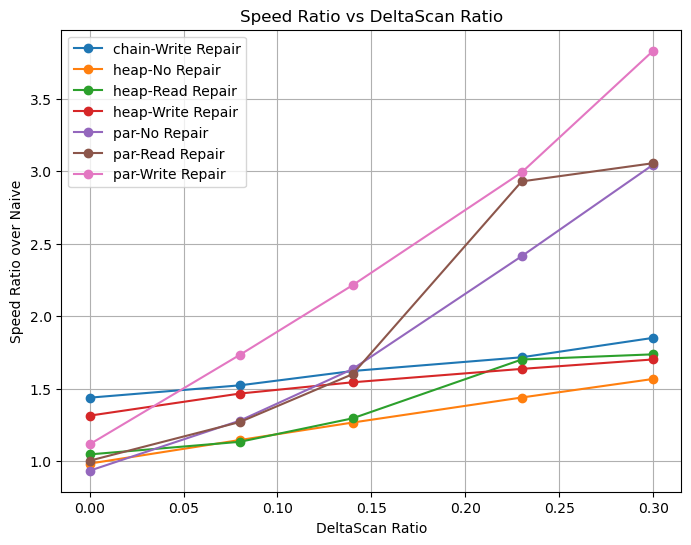

In [27]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TXN_UPDATE_RATIO = 0.2
TXN_GC_RATIO = 0.03

BASE_ARGS = [
    "--txn-count", "50",  
    "--update-ratio", "0.003",
    "--warehouse-count", "35", # linear to base table size
    "--probe-ratio", "0.0001",
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO)
]

REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = [0.00, 0.08, 0.14, 0.23, 0.30] # (txn_delta_ratio) # , 0.12, 0.16

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, txn_delta_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"txn_delta_ratio": txn_delta_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res
df_ratio = pd.DataFrame()
df_list = []
for txn_delta_ratio in REUSE_CONFIGS:
    analytical_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO
    assert (txn_delta_ratio < analytical_ratio)
    scan_and_probe = analytical_ratio - txn_delta_ratio
    txn_probe_ratio = scan_and_probe / 2
    txn_scan_ratio = scan_and_probe / 2
    appended_args = [
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio),
        "--txn-scan-ratio", str(txn_scan_ratio)
    ]


    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += appended_args
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
    display_all_txns(df)
    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
    df_avg = get_avg(result)
    # print(aa)
    ratio = get_ratio(df_avg, 'naive', txn_delta_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
    # display(result)
    df_list.append(result)



df = df_ratio.sort_values(by="txn_delta_ratio")

# (table_type, repair_type) 
plt.figure(figsize=(8,6))
for (table, repair), group in df.groupby(["table_type", "repair_type"]):
    plt.plot(group["txn_delta_ratio"], group["speed_ratio_over_naive"], 
             marker='o', label=f"{table}-{repair}")

plt.xlabel("DeltaScan Ratio")
plt.ylabel("Speed Ratio over Naive")
plt.title("Speed Ratio vs DeltaScan Ratio")
plt.legend()
plt.grid(True)
plt.show()

# assert(len(df_list) > 1)
# df_first = df_list[0]
# df_last = df_list[-1]
# merged = pd.merge(
#     df_first,
#     df_last,
#     on=["table_type", "repair_type", "tx_type"],
#     how="inner",
#     suffixes=("_first", "_last")
# )

# df_filtered = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
# )]

# merged = df_filtered

# # 
# merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# # 
# group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# # 
# merged["pct_contribution"] = merged["delta"] / group_total * 100
# display(merged)
# def stack_bar_chart_for_contribution(df, min_pct=0.02):
#     # create a new column combining table_type and repair_type for x labels
#     df["group"] = df["table_type"] + "\n" + df["repair_type"]

#     # pivot so that tx_type becomes columns, pct_contribution values are stacked
#     pivot_df = df.pivot_table(
#         index="group",
#         columns="tx_type",
#         values="pct_contribution",
#         aggfunc="sum",
#         fill_value=0
#     )

#     display(pivot_df)

#     # plot stacked bar
#     ax = pivot_df.plot(
#         kind="bar",
#         stacked=True,
#         figsize=(10, 6)
#     )
    
#     # add labels and title
#     plt.ylabel("Pct Contribution (%)")
#     plt.xlabel("Table Type - Repair Type")
#     plt.xticks(rotation=0)
#     plt.title("Operation Contribution Percentage(%) on Speed Degradation(DeltaScan Intensity)")
#     plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
#     plt.tight_layout()
#     plt.show()
# ############################################################################################################
#     # create one subplot per group
#     n_groups = len(pivot_df)
#     fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

#     # if only one group, axes is not iterable
#     if n_groups == 1:
#         axes = [axes]

#     for ax, (group, row) in zip(axes, pivot_df.iterrows()):
#         row = row[row > 0]
#         row = row / row.sum()

#         # merge tiny slices into "Others"
#         small = row[row < min_pct]
#         row = row[row >= min_pct]
#         if len(small) > 0:
#             row["Others"] = small.sum()
        
#         # draw pie chart
#         ax.pie(
#             row.values,
#             labels=row.index,
#             autopct="%1.1f%%",
#             startangle=90,
#             counterclock=False
#         )
#         ax.set_title(group)

#     plt.tight_layout()
#     plt.show()

# df_filtered1 = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
# )]


# df_filtered = df_filtered1[~(
#     df_filtered1["table_type"].isin(["naive"])
# )]


# stack_bar_chart_for_contribution(df_filtered)


# DELTA TRADEOFF -- update ratio (CONFIG)

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.003', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transac

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.939623
1,chain,No Repair,InitLoad,754.058164
2,chain,No Repair,MarkTs,0.000000
3,chain,No Repair,Probe,2261.167000
4,chain,No Repair,Scan,9195.930901
5,chain,No Repair,Update,3054.152403
6,chain,Read Repair,GbgCollect,0.903682
7,chain,Read Repair,InitLoad,758.260735
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,2247.664432


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.008', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.008
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,2.043643
1,chain,No Repair,InitLoad,769.780805
2,chain,No Repair,MarkTs,0.000000
3,chain,No Repair,Probe,2371.208436
4,chain,No Repair,Scan,8722.580242
5,chain,No Repair,Update,3290.088066
6,chain,Read Repair,GbgCollect,2.058358
7,chain,Read Repair,InitLoad,738.871326
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,2360.207340


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.015', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.015
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
------------------------------------------------

...

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.022', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.022
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,5.430216
1,chain,No Repair,InitLoad,784.490253
2,chain,No Repair,MarkTs,0.000000
3,chain,No Repair,Probe,2798.499822
4,chain,No Repair,Scan,8956.839083
5,chain,No Repair,Update,4578.989711
6,chain,Read Repair,GbgCollect,5.435876
7,chain,Read Repair,InitLoad,776.497790
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,2816.650810


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.03', '--txn-scan-ratio', '0.235', '--txn-probe-ratio', '0.235', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.03
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.235)
Transactions Scan ratio: Some(0.235)
Transactions Delta Scan ratio: Some(0.0)
--------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,7.098108
1,chain,No Repair,InitLoad,767.947833
2,chain,No Repair,MarkTs,0.000000
3,chain,No Repair,Probe,2961.530206
4,chain,No Repair,Scan,10067.578852
5,chain,No Repair,Update,5286.515531
6,chain,Read Repair,GbgCollect,7.226561
7,chain,Read Repair,InitLoad,739.449874
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,2970.959255


,tx_type,count,percentage
0,GbgCollect,2,2.941176
1,InitLoad,1,1.470588
2,MarkTs,5,7.352941
3,Probe,14,20.588235
4,Scan,14,20.588235
5,Update,32,47.058824


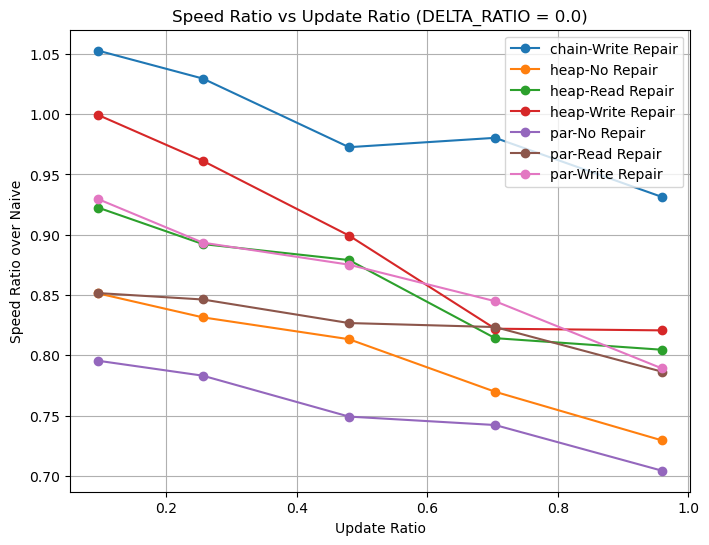

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.003', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7669.486989
1,chain,No Repair,GbgCollect,0.937913
2,chain,No Repair,InitLoad,759.862403
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,1784.843671
5,chain,No Repair,Scan,7334.310472
6,chain,No Repair,Update,2878.324668
7,chain,Read Repair,DeltaScan,7634.403915
8,chain,Read Repair,GbgCollect,0.903896
9,chain,Read Repair,InitLoad,736.446735


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.008', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.008
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,8666.548099
1,chain,No Repair,GbgCollect,2.116696
2,chain,No Repair,InitLoad,764.339364
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,1950.173096
5,chain,No Repair,Scan,7167.722558
6,chain,No Repair,Update,3292.651268
7,chain,Read Repair,DeltaScan,8710.297522
8,chain,Read Repair,GbgCollect,2.134129
9,chain,Read Repair,InitLoad,756.779336


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.015', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.015
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

...

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.022', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.022
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,9624.283354
1,chain,No Repair,GbgCollect,5.350324
2,chain,No Repair,InitLoad,742.075192
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,2147.839272
5,chain,No Repair,Scan,7253.456994
6,chain,No Repair,Update,4526.947827
7,chain,Read Repair,DeltaScan,9748.712489
8,chain,Read Repair,GbgCollect,5.318000
9,chain,Read Repair,InitLoad,743.971315


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--warehouse-count', '35', '--probe-ratio', '0.0001', '--txn-update-ratio', '0.5', '--txn-gc-ratio', '0.03', '--seed', '74367232', '--update-ratio', '0.03', '--txn-scan-ratio', '0.185', '--txn-probe-ratio', '0.185', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 74367232
-----------------------------------------------------------------------

Update ratio: 0.03
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.5)
Transactions Probe ratio: Some(0.185)
Transactions Scan ratio: Some(0.185)
Transactions Delta Scan ratio: Some(0.1)
--------------------------------------------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,10265.235678
1,chain,No Repair,GbgCollect,7.406469
2,chain,No Repair,InitLoad,819.109184
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,2712.123731
5,chain,No Repair,Scan,8880.439157
6,chain,No Repair,Update,5592.548934
7,chain,Read Repair,DeltaScan,10018.378134
8,chain,Read Repair,GbgCollect,7.350203
9,chain,Read Repair,InitLoad,768.610488


,tx_type,count,percentage
0,DeltaScan,6,8.955224
1,GbgCollect,2,2.985075
2,InitLoad,1,1.492537
3,MarkTs,4,5.970149
4,Probe,11,16.417910
5,Scan,11,16.417910
6,Update,32,47.761194


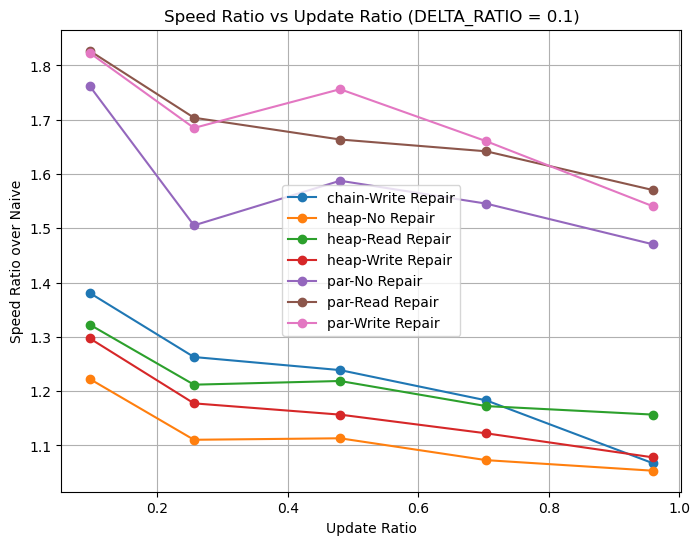

In [28]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TXN_UPDATE_RATIO = 0.5
TXN_GC_RATIO = 0.03
BASE_ARGS = [
    "--txn-count", "60",  
    "--warehouse-count", "35", # linear to base table size
    "--probe-ratio", "0.0001",
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO),
    "--seed", "74367232"
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
UPDATE_RATIOS = ["0.003", "0.008", "0.015", "0.022","0.03"] # , "0.015", "0.03"

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res

def run_and_draw(txn_delta_ratio):
    
    assert ((1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO) > (txn_delta_ratio - 1e-6))
    analytical_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_GC_RATIO
    txn_probe_ratio = (analytical_ratio - txn_delta_ratio) / 2
    txn_scan_ratio = txn_probe_ratio
    appended_args = [
        "--txn-scan-ratio", str(txn_scan_ratio),
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio)
    ]
    df_ratio = pd.DataFrame()
    df_list = []
    update_count = 0
    last_df = None
    for update_ratio in UPDATE_RATIOS:
        NEW_ARGS = BASE_ARGS.copy()
        NEW_ARGS += ["--update-ratio", update_ratio]
        NEW_ARGS += appended_args
        
        df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)
        update_count = (
            df[df["tx_type"] == "Update"]
            .groupby(["table_type", "repair_type"])
            .size()
            .iloc[0]   
        )
        # Display the resulting DataFrame
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
        print(f"update_ratio: {update_ratio}")
        display(result)
        df_avg = get_avg(result)
        # print(aa)
        ratio = get_ratio(df_avg, 'naive', update_ratio)
        df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
        # display(result)
        df_list.append(result)
        last_df = df


    display_all_txns(last_df)
    # assert(len(df_list) > 1)
    # df_first = df_list[0]
    # df_last = df_list[-1]
    # merged = pd.merge(
    #     df_first,
    #     df_last,
    #     on=["table_type", "repair_type", "tx_type"],
    #     how="inner",
    #     suffixes=("_first", "_last")
    # )


    # print(f"update_count : {update_count}")


    df_ratio['update_ratio'] = df_ratio['update_ratio'].astype(float) * update_count
    # display(df_ratio)
    df = df_ratio.sort_values(by="update_ratio")

    # 按 (table_type, repair_type) 分组画图
    plt.figure(figsize=(8,6))
    for (table, repair), group in df.groupby(["table_type", "repair_type"]):
        plt.plot(group["update_ratio"], group["speed_ratio_over_naive"], 
                marker='o', label=f"{table}-{repair}")

    plt.xlabel("Update Ratio")
    plt.ylabel("Speed Ratio over Naive")
    plt.title(f"Speed Ratio vs Update Ratio (DELTA_RATIO = {txn_delta_ratio})")
    plt.legend()
    plt.grid(True)
    plt.show()

run_and_draw(txn_delta_ratio=0.0)
run_and_draw(txn_delta_ratio=0.10)


# df_filtered = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
# )]

# merged = df_filtered

# # 增长量
# merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# # 总增长（每组 table_type + repair_type）
# group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# # 每个 tx_type 对增长的百分比贡献
# merged["pct_contribution"] = merged["delta"] / group_total * 100
# display(merged)

# def stack_bar_chart_for_contribution(df, min_pct=0.02):
#     # create a new column combining table_type and repair_type for x labels
#     df["group"] = df["table_type"] + "\n" + df["repair_type"]

#     # pivot so that tx_type becomes columns, pct_contribution values are stacked
#     pivot_df = df.pivot_table(
#         index="group",
#         columns="tx_type",
#         values="pct_contribution",
#         aggfunc="sum",
#         fill_value=0
#     )

#     # plot stacked bar
#     ax = pivot_df.plot(
#         kind="bar",
#         stacked=True,
#         figsize=(10, 6)
#     )
    
#     # add labels and title
#     plt.ylabel("Pct Contribution (%)")
#     plt.xlabel("Table Type - Repair Type")
#     plt.xticks(rotation=0)
#     plt.title("Operation Contribution Percentage(%) on Speed Degradation")
#     plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
#     plt.tight_layout()
#     plt.show()
# ############################################################################################################
#     # create one subplot per group
#     n_groups = len(pivot_df)
#     fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

#     # if only one group, axes is not iterable
#     if n_groups == 1:
#         axes = [axes]

#     for ax, (group, row) in zip(axes, pivot_df.iterrows()):
#         row = row[row > 0]
#         row = row / row.sum()

#         # merge tiny slices into "Others"
#         small = row[row < min_pct]
#         row = row[row >= min_pct]
#         if len(small) > 0:
#             row["Others"] = small.sum()
        
#         # draw pie chart
#         ax.pie(
#             row.values,
#             labels=row.index,
#             autopct="%1.1f%%",
#             startangle=90,
#             counterclock=False
#         )
#         ax.set_title(group)

#     plt.tight_layout()
#     plt.show()

# df_filtered1 = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
# )]


# df_filtered = df_filtered1[~(
#     df_filtered1["table_type"].isin(["naive"])
# )]


# stack_bar_chart_for_contribution(df_filtered)


# DELTA TRACEOFF -- reuse of snapshots (TBD)

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.1', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']


-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
-----------------------------------------------------------------------


txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 1050000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3150
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     MarkTs, Mark Ts: 3
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update co

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.893758
1,chain,No Repair,InitLoad,749.183619
2,chain,No Repair,MarkTs,0.001005
3,chain,No Repair,Probe,1541.027442
4,chain,No Repair,Scan,19720.248046
5,chain,No Repair,Update,1857.515668
6,chain,Read Repair,GbgCollect,0.914713
7,chain,Read Repair,InitLoad,741.292840
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,1612.239631


,tx_type,count,percentage
0,GbgCollect,2,2.127660
1,InitLoad,1,1.063830
2,MarkTs,31,32.978723
3,Probe,10,10.638298
4,Scan,30,31.914894
5,Update,20,21.276596


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.2', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
----------------

...

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.928991
1,chain,No Repair,InitLoad,762.846979
2,chain,No Repair,MarkTs,0.001052
3,chain,No Repair,Probe,1560.427982
4,chain,No Repair,Scan,20154.672411
5,chain,No Repair,Update,1972.006366
6,chain,Read Repair,GbgCollect,0.914543
7,chain,Read Repair,InitLoad,738.792901
8,chain,Read Repair,MarkTs,0.001297
9,chain,Read Repair,Probe,1594.384626


,tx_type,count,percentage
0,GbgCollect,2,2.702703
1,InitLoad,1,1.351351
2,MarkTs,11,14.864865
3,Probe,10,13.513514
4,Scan,30,40.540541
5,Update,20,27.027027


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.8', '--txn-probe-ratio', '0.16999999999999996', '--txn-delta-ratio', '0.0', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.16999999999999996)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.0)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,GbgCollect,0.893570
1,chain,No Repair,InitLoad,756.591123
2,chain,No Repair,MarkTs,0.000000
3,chain,No Repair,Probe,1563.874260
4,chain,No Repair,Scan,19442.987913
5,chain,No Repair,Update,1851.302388
6,chain,Read Repair,GbgCollect,0.914555
7,chain,Read Repair,InitLoad,757.642815
8,chain,Read Repair,MarkTs,0.000000
9,chain,Read Repair,Probe,1638.075486


,tx_type,count,percentage
0,GbgCollect,2,2.941176
1,InitLoad,1,1.470588
2,MarkTs,5,7.352941
3,Probe,10,14.705882
4,Scan,30,44.117647
5,Update,20,29.411765


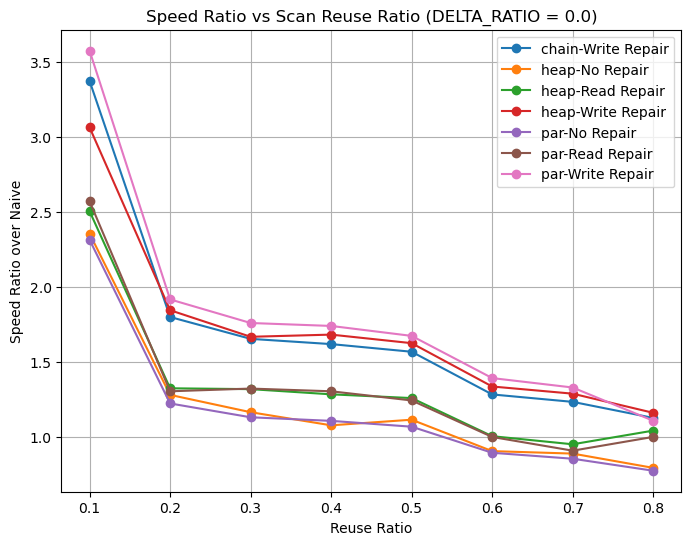

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.1', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7425.933693
1,chain,No Repair,GbgCollect,0.947238
2,chain,No Repair,InitLoad,771.348424
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,626.281266
5,chain,No Repair,Scan,19821.398201
6,chain,No Repair,Update,1882.765288
7,chain,Read Repair,DeltaScan,7430.732331
8,chain,Read Repair,GbgCollect,0.942419
9,chain,Read Repair,InitLoad,746.418544


,tx_type,count,percentage
0,DeltaScan,6,6.382979
1,GbgCollect,2,2.127660
2,InitLoad,1,1.063830
3,MarkTs,31,32.978723
4,Probe,4,4.255319
5,Scan,30,31.914894
6,Update,20,21.276596


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.2', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7293.124875
1,chain,No Repair,GbgCollect,0.937649
2,chain,No Repair,InitLoad,755.284994
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,614.422155
5,chain,No Repair,Scan,20153.909588
6,chain,No Repair,Update,1933.774303
7,chain,Read Repair,DeltaScan,7264.332740
8,chain,Read Repair,GbgCollect,0.938374
9,chain,Read Repair,InitLoad,770.944293


...

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7461.663136
1,chain,No Repair,GbgCollect,0.937045
2,chain,No Repair,InitLoad,763.321163
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,586.405419
5,chain,No Repair,Scan,19908.835557
6,chain,No Repair,Update,1894.356739
7,chain,Read Repair,DeltaScan,7525.802867
8,chain,Read Repair,GbgCollect,0.958823
9,chain,Read Repair,InitLoad,754.866382


,tx_type,count,percentage
0,DeltaScan,6,8.333333
1,GbgCollect,2,2.777778
2,InitLoad,1,1.388889
3,MarkTs,9,12.500000
4,Probe,4,5.555556
5,Scan,30,41.666667
6,Update,20,27.777778


Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '60', '--update-ratio', '0.003', '--probe-ratio', '0.0001', '--warehouse-count', '35', '--txn-update-ratio', '0.3', '--txn-scan-ratio', '0.5', '--txn-gc-ratio', '0.03', '--scan-reuse-ratio', '0.8', '--txn-probe-ratio', '0.06999999999999995', '--txn-delta-ratio', '0.1', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.003
probe ratio: 0.0001
Analytical ratio: None
Number of transactions (max Timestamp value): 60
Number of each scan transactions: 3

-----------------------------------------------------------------------
Transactions Update ratio: Some(0.3)
Transactions Probe ratio: Some(0.06999999999999995)
Transactions Scan ratio: Some(0.5)
Transactions Delta Scan ratio: Some(0.1)
----------------

,table_type,repair_type,tx_type,duration_ms
0,chain,No Repair,DeltaScan,7552.767568
1,chain,No Repair,GbgCollect,0.915417
2,chain,No Repair,InitLoad,746.664230
3,chain,No Repair,MarkTs,0.000000
4,chain,No Repair,Probe,619.246543
5,chain,No Repair,Scan,19950.470804
6,chain,No Repair,Update,1921.890991
7,chain,Read Repair,DeltaScan,7633.732799
8,chain,Read Repair,GbgCollect,0.950911
9,chain,Read Repair,InitLoad,752.921042


,tx_type,count,percentage
0,DeltaScan,6,8.695652
1,GbgCollect,2,2.898551
2,InitLoad,1,1.449275
3,MarkTs,6,8.695652
4,Probe,4,5.797101
5,Scan,30,43.478261
6,Update,20,28.985507


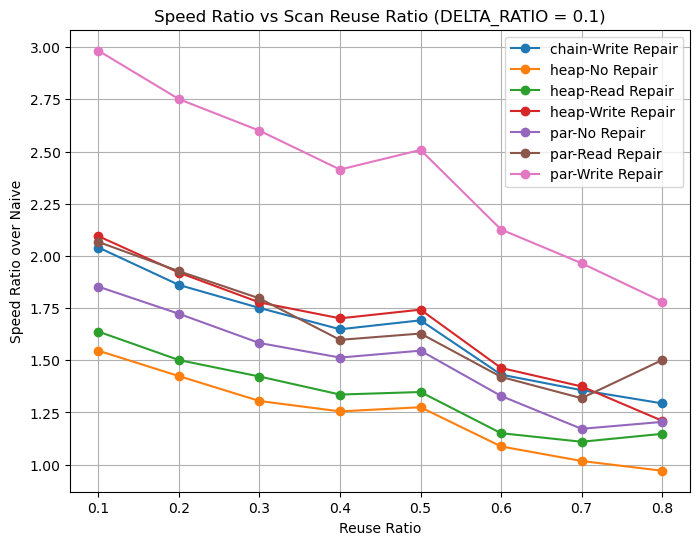

In [29]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

TXN_UPDATE_RATIO = 0.3
TXN_SCAN_RATIO = 0.5
TXN_GC_RATIO = 0.03
BASE_ARGS = [
    "--txn-count", "60",  
    "--update-ratio", "0.003",
    "--probe-ratio", "0.0001",
    "--warehouse-count", "35", # linear to base table size
    "--txn-update-ratio", str(TXN_UPDATE_RATIO),
    "--txn-scan-ratio", str(TXN_SCAN_RATIO),
    "--txn-gc-ratio", str(TXN_GC_RATIO)
]


REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"] #, "par", "chain"
REUSE_CONFIGS = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8"] # , "0.4", "0.8"

from bench_script_functions import run_and_collect, display_all_txns
TRANSACTIONAL_TX_TYPE = ['InitLoad', 'Update']
ANALYTICAL_TX_TYPE = ['Probe', 'Scan', 'DeltaScan']

def get_avg(df):
    # display(df)
    table_types = sorted(df['table_type'].unique())
    repair_types = ["No Repair", "Read Repair", "Write Repair"]
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        # scan_vals = df_group['duration_ms'].values
        # avg_delta_scan = scan_vals.sum()
        # display(df_group)
        scan_vals = df_group['duration_ms'].sum()
        durations.append((table_type, repair_type, scan_vals)) # table_type, repair_type, avg_duration

        # display(df_group)
    return durations

# get ratio over base_type
def get_ratio(avg, base_type, scan_reuse_ratio):
    result = []
    ratio_col_name = f'speed_ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"scan_reuse_ratio": scan_reuse_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: base/ avg_dur})

    df_res = pd.DataFrame(result)
    return df_res

def run_and_draw(txn_delta_ratio):
    assert ((1.0 - TXN_UPDATE_RATIO - TXN_SCAN_RATIO) > (txn_delta_ratio - 1e-6))
    delta_and_probe_ratio = 1.0 - TXN_UPDATE_RATIO - TXN_SCAN_RATIO - TXN_GC_RATIO
    txn_probe_ratio = delta_and_probe_ratio - txn_delta_ratio
    appended_args = [
        "--txn-probe-ratio", str(txn_probe_ratio),
        "--txn-delta-ratio", str(txn_delta_ratio)
    ]
    df_ratio = pd.DataFrame()
    df_list = []
    last_df = None
    for scan_reuse_ratio in REUSE_CONFIGS:
        NEW_ARGS = BASE_ARGS.copy()
        NEW_ARGS += ["--scan-reuse-ratio", scan_reuse_ratio]
        NEW_ARGS += appended_args
        
        df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)

        # Display the resulting DataFrame
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', None)
        result = df.groupby(["table_type", "repair_type", "tx_type"])["duration_ms"].sum().reset_index()
        df_avg = get_avg(result)
        # print(aa)
        ratio = get_ratio(df_avg, 'naive', scan_reuse_ratio)
        df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
        display(result)
        df_list.append(result)
        display_all_txns(df)


    df = df_ratio.sort_values(by="scan_reuse_ratio")

    # (table_type, repair_type) 
    plt.figure(figsize=(8,6))
    for (table, repair), group in df.groupby(["table_type", "repair_type"]):
        plt.plot(group["scan_reuse_ratio"], group["speed_ratio_over_naive"], 
                marker='o', label=f"{table}-{repair}")

    plt.xlabel("Reuse Ratio")
    plt.ylabel("Speed Ratio over Naive")
    plt.title(f"Speed Ratio vs Scan Reuse Ratio (DELTA_RATIO = {txn_delta_ratio})")
    plt.legend()
    plt.grid(True)
    plt.show()
run_and_draw(txn_delta_ratio=0.0)
run_and_draw(txn_delta_ratio=0.1)

# assert(len(df_list) > 1)
# df_first = df_list[0]
# df_last = df_list[-1]
# merged = pd.merge(
#     df_first,
#     df_last,
#     on=["table_type", "repair_type", "tx_type"],
#     how="inner",
#     suffixes=("_first", "_last")
# )

# df_filtered = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair")) | merged["table_type"] == "naive"
# )]

# merged = df_filtered

# # 
# merged["delta"] = merged["duration_ms_last"] - merged["duration_ms_first"]

# # 
# group_total = merged.groupby(["table_type", "repair_type"])["delta"].transform("sum")

# # 
# merged["pct_contribution"] = merged["delta"] / group_total * 100
# display(merged)
# def stack_bar_chart_for_contribution(df, min_pct=0.02):
#     # create a new column combining table_type and repair_type for x labels
#     df["group"] = df["table_type"] + "\n" + df["repair_type"]

#     # pivot so that tx_type becomes columns, pct_contribution values are stacked
#     pivot_df = df.pivot_table(
#         index="group",
#         columns="tx_type",
#         values="pct_contribution",
#         aggfunc="sum",
#         fill_value=0
#     )

#     display(pivot_df)

#     # plot stacked bar
#     ax = pivot_df.plot(
#         kind="bar",
#         stacked=True,
#         figsize=(10, 6)
#     )
    
#     # add labels and title
#     plt.ylabel("Pct Contribution (%)")
#     plt.xlabel("Table Type - Repair Type")
#     plt.xticks(rotation=0)
#     plt.title("Operation Contribution Percentage(%) on Speed Degradation(REUSE of TIME)")
#     plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
#     plt.tight_layout()
#     plt.show()
# ############################################################################################################
#     # create one subplot per group
#     n_groups = len(pivot_df)
#     fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 5))

#     # if only one group, axes is not iterable
#     if n_groups == 1:
#         axes = [axes]

#     for ax, (group, row) in zip(axes, pivot_df.iterrows()):
#         row = row[row > 0]
#         row = row / row.sum()

#         # merge tiny slices into "Others"
#         small = row[row < min_pct]
#         row = row[row >= min_pct]
#         if len(small) > 0:
#             row["Others"] = small.sum()
        
#         # draw pie chart
#         ax.pie(
#             row.values,
#             labels=row.index,
#             autopct="%1.1f%%",
#             startangle=90,
#             counterclock=False
#         )
#         ax.set_title(group)

#     plt.tight_layout()
#     plt.show()

# df_filtered1 = merged[~(
#     (merged["table_type"].isin(["naive", "chain"]) & (merged["repair_type"] != "Write Repair"))
# )]


# df_filtered = df_filtered1[~(
#     df_filtered1["table_type"].isin(["naive"])
# )]


# stack_bar_chart_for_contribution(df_filtered)
